Problem Statement: Build your own recommendation system for products on an e-commerce website like Amazon.com. 

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Statements**

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

**Read and Explore Electronics Ratings Dataset**

In [0]:
elect_ratings_df = pd.read_csv("/content/drive/My Drive/GreatLakes/Recommendation/ratings_Electronics.csv")

In [3]:
elect_ratings_df.info()
# Total around 7.82 million observations
# Total 4 columns [Two numeric and two objects]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824481 entries, 0 to 7824480
Data columns (total 4 columns):
AKM1MP6P0OYPR    object
0132793040       object
5.0              float64
1365811200       int64
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


In [4]:
#Check Top few rows
elect_ratings_df.head()

,AKM1MP6P0OYPR,0132793040,5.0,1365811200
0,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
1,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
2,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
3,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
4,A1QGNMC6O1VW39,0511189877,5.0,1397433600


In [5]:
#Check last few rows
elect_ratings_df.tail()

,AKM1MP6P0OYPR,0132793040,5.0,1365811200
7824476,A2YZI3C9MOHC0L,BT008UKTMW,5.0,1396569600
7824477,A322MDK0M89RHN,BT008UKTMW,5.0,1313366400
7824478,A1MH90R0ADMIK0,BT008UKTMW,4.0,1404172800
7824479,A10M2KEFPEQDHN,BT008UKTMW,4.0,1297555200
7824480,A2G81TMIOIDEQQ,BT008V9J9U,5.0,1312675200


**Missing Value Check**

In [6]:
elect_ratings_df.isnull().sum()
# No missing values exist

AKM1MP6P0OYPR    0
0132793040       0
5.0              0
1365811200       0
dtype: int64

**Renaming and Removing Unwanted Columns**




In [7]:
#As per RS_Amazon Product Recommendation.pdf, first three columns are userId, productId, and ratings and the fourth column is timestamp. 
#You can discard the timestamp column as in this case you may not need to use it. 
elect_ratings_df.rename(columns = {'AKM1MP6P0OYPR':'userid', '0132793040':'productid', '5.0':'ratings'}, inplace = True)
print(elect_ratings_df.columns)

Index(['userid', 'productid', 'ratings', '1365811200'], dtype='object')


In [0]:
elect_ratings_df.drop(columns="1365811200", axis=1, inplace=True, errors='ignore')

In [9]:
elect_ratings_df.head()

,userid,productid,ratings
0,A2CX7LUOHB2NDG,0321732944,5.0
1,A2NWSAGRHCP8N5,0439886341,1.0
2,A2WNBOD3WNDNKT,0439886341,3.0
3,A1GI0U4ZRJA8WN,0439886341,1.0
4,A1QGNMC6O1VW39,0511189877,5.0


In [10]:
elect_ratings_df.tail()

,userid,productid,ratings
7824476,A2YZI3C9MOHC0L,BT008UKTMW,5.0
7824477,A322MDK0M89RHN,BT008UKTMW,5.0
7824478,A1MH90R0ADMIK0,BT008UKTMW,4.0
7824479,A10M2KEFPEQDHN,BT008UKTMW,4.0
7824480,A2G81TMIOIDEQQ,BT008V9J9U,5.0


**Exploring the ratings data**

In [11]:
elect_ratings_df.describe().T
# Ratings range from 1 to 5
# Mean ratings of 4 is less than median rating of 5

,count,mean,std,min,25%,50%,75%,max
ratings,7824481.0,4.012337,1.38091,1.0,3.0,5.0,5.0,5.0


In [12]:
elect_ratings_df.describe(include='object').T
# OBSERVATIONS
# 1. Only 4201696 users exist so many users have given multiple ratings(total 520).
# A5JLAU2ARJ0BO user Id has mAximum occurences indicating he has given maximum ratings
#
# 2.Product with ID B0074BW614 has maximum frequency indicating it has received 
# maximum count of ratings. Curious to know what is the rating given to this item
#
# 3. Number of unique users > Number of unique Products
#
# 4. User with ID A5JLAU2ARJ0BO has given maximum ratings of 520. Curious to know 
# what kind of ratings this active user has given

,count,unique,top,freq
userid,7824481,4201696,A5JLAU2ARJ0BO,520
productid,7824481,476001,B0074BW614,18244


In [13]:
#Break down of 18244 ratings received by product B0074BW614 
elect_ratings_df[elect_ratings_df.productid == 'B0074BW614']['ratings'].value_counts()
# OBSERVATION: This product has received mostly 5 , 4 and 3 ratings. Seems to be extremely popular item

5.0    12765
4.0     3333
3.0     1058
1.0      564
2.0      524
Name: ratings, dtype: int64

In [14]:
#Break down of 512 ratings given by user 'A5JLAU2ARJ0BO' 
elect_ratings_df[elect_ratings_df.userid == 'A5JLAU2ARJ0BO']['ratings'].value_counts()
#OBSERVATION: This user has mostly given 5 ratings for most of the items

5.0    275
4.0     83
1.0     67
2.0     51
3.0     44
Name: ratings, dtype: int64

In [0]:
#data = elect_ratings_df['ratings'].value_counts().sort_index(ascending=False)
#labels = elect_ratings_df['ratings'].unique()

#plt.show()

In [16]:
#Get the breakdown of number of ratings for each rating value
elect_ratings_df['ratings'].value_counts()
#OBSERVATION: Rating counts are in the order 5>4>1>3>2. Most users have rated most of the products as 5

5.0    4347540
4.0    1485781
1.0     901765
3.0     633073
2.0     456322
Name: ratings, dtype: int64

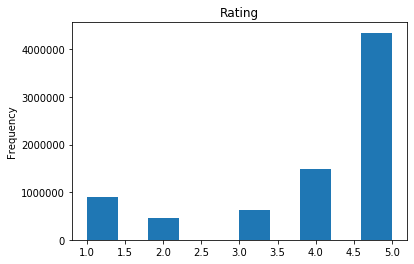

In [17]:
elect_ratings_df['ratings'].plot(kind='hist', title='Rating')
#The above counts of various ratings are represented as histogram


In [0]:
#Since maximum rating value is 5. Let us see which products have received maximum rating of 5 
#elect_ratings_df[elect_ratings_df['ratings']== 5]

In [0]:
#user_frequency_df = pd.DataFrame(elect_ratings_df.groupby('userid')['ratings'].count()) 
#user_frequency_df.head()

**Take a subset of the dataset to make it less sparse/ denser**

In [0]:
# We have 7824481 entries in dataframe and each entry has userid , product id and ratings.
# Total products are 476001 and tota users are 4201696. All users have not rated all the products.Maximum frequency of rating 
# done by a user is 520. Thus the matrix corresponding to this dataframe is heavily sparse though the zero values are not stored
# in the dataframe
# Our dataframe doesnot have 0 values but we are making it little more denser by removing inactive users. Inactive users are
# those usrs who have given less than 50 ratings (rated less than 50 products)

In [0]:
#user_frequency_df = pd.DataFrame(elect_ratings_df.groupby('userid')['ratings'].count()) 

In [22]:
#Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 
#50 or more number of ratings )
#System crashes for threshold of count of ratings as 50 so we reduce further by keeping products who have
#received more than 50 ratings
# 
MIN_USER_RATINGS=50
MIN_PROD_RATINGS=50

active_users = elect_ratings_df['userid'].value_counts() > MIN_USER_RATINGS
active_users = active_users[active_users].index.tolist()


active_prods = elect_ratings_df['productid'].value_counts() > MIN_PROD_RATINGS
active_prods = active_prods[active_prods].index.tolist()

elect_dense_df = elect_ratings_df[(elect_ratings_df['productid'].isin(active_prods)) & 
                                  (elect_ratings_df['userid'].isin(active_users))]
print('The original data frame shape:\t{}'.format(elect_ratings_df.shape))
print('The new data frame shape:\t{}'.format(elect_dense_df.shape))

#active_users = list(set(user_frequency_df.query('ratings > @MIN_USER_RATINGS').index))
#elect_dense_df = elect_ratings_df[elect_ratings_df.userid.isin(active_users)]
#print(elect_dense_df.shape)
#print(elect_dense_df['userid'].nunique())

The original data frame shape:	(7824481, 3)
The new data frame shape:	(76359, 3)


**EDA of sparse dataset**

In [23]:
elect_dense_df.head()

,userid,productid,ratings
491,A3CLWR1UUZT6TG,0972683275,5.0
630,A3TAS1AG6FMBQW,0972683275,5.0
1137,A25RTRAPQAJBDJ,0972683275,5.0
1309,A3LDPF5FMB782Z,1400501466,5.0
1321,A1A5KUIIIHFF4U,1400501466,1.0


In [24]:
elect_dense_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ratings,76359.0,4.29783,1.028477,1.0,4.0,5.0,5.0,5.0


In [25]:
elect_dense_df.describe(include='object').T

,count,unique,top,freq
userid,76359,1466,ADLVFFE4VBT8,310
productid,76359,16555,B0088CJT4U,204


3. **Build Popularity Recommender model.**

In [26]:
#If we associate popularity with number ofratings
elect_dense_df.groupby('productid')['ratings'].count().sort_values(ascending=False).head(10)

productid
B0088CJT4U    204
B003ES5ZUU    177
B000N99BBC    163
B007WTAJTO    156
B00829TIEK    146
B008DWCRQW    135
B00829THK0    132
B002R5AM7C    127
B004CLYEDC    117
B004T9RR6I    108
Name: ratings, dtype: int64

In [27]:
elect_dense_df.groupby('productid')['ratings'].mean().sort_values(ascending=False).head(10) 
#OBSERVATION:
#Many of the highly rated products below (rating 5) are not having many contributing ratings as seen in count of ratings in
#previous cell . So products with high mean rating donot have many ratings so one to many users could have contributed to 
#popularity based on mean ratings 

productid
B00L3YHF6O    5.0
B003INFE16    5.0
B003JBVX5S    5.0
B003JC3Z58    5.0
B003JH7KT0    5.0
B003JHJL38    5.0
B003JL7XFM    5.0
B003JOETX8    5.0
B003JOPWHK    5.0
B003JTHMQO    5.0
Name: ratings, dtype: float64

In [28]:
#Let us create a dataframe to store mean ratings of product
product_rating_df = pd.DataFrame(elect_dense_df.groupby('productid')['ratings'].mean())
product_rating_df.head(10)

,ratings
productid,
0972683275,5.00
1400501466,3.00
1400501520,5.00
1400501776,4.50
1400532620,3.00
1400532655,3.60
140053271X,2.50
1400599997,3.75
1400698987,4.50


In [29]:
product_rating_df['ratingcount'] = elect_dense_df.groupby('productid')['ratings'].count()
product_rating_df.head(10)
#How many ratings are contributing to particular mean rating are added as 'ratingcount' column 

,ratings,ratingcount
productid,,
0972683275,5.00,3
1400501466,3.00,5
1400501520,5.00,1
1400501776,4.50,2
1400532620,3.00,2
1400532655,3.60,5
140053271X,2.50,2
1400599997,3.75,4
1400698987,4.50,2


In [30]:
product_rating_df.tail()

,ratings,ratingcount
productid,,
B00K91DB7Y,4.153846,26
B00KFAGCUM,4.857143,7
B00KINSDK8,5.000000,1
B00KWHMR6G,1.500000,2
B00L3YHF6O,5.000000,14


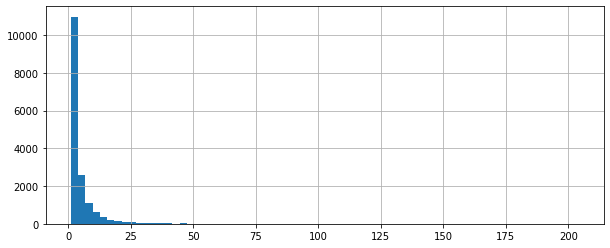

In [31]:
plt.figure(figsize=(10,4))
product_rating_df['ratingcount'].hist(bins=70)
#around 10000 products have been rated by max 5 users and there are below 2500 products who have been rated by more than 5 users
#Should we consider popularity as rated by many users or rated by many as well as high rating
# So products with minimum count of ratings are almost 4 times the products with higher number of users contribting to their rating

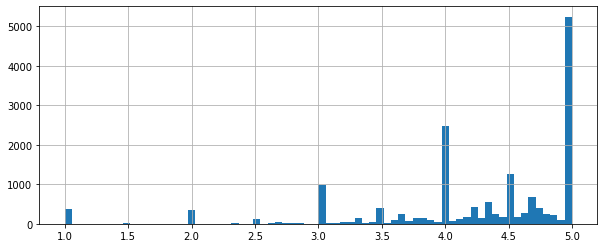

In [32]:
plt.figure(figsize=(10,4))
product_rating_df['ratings'].hist(bins=70)
# Ratings are not consistent. Maximum products(around 5000) have  rating of 5, followed by 4, 3,1 and 2.
# Number of products with 5 mean ratings are almost twice the number of users with 4 ratings

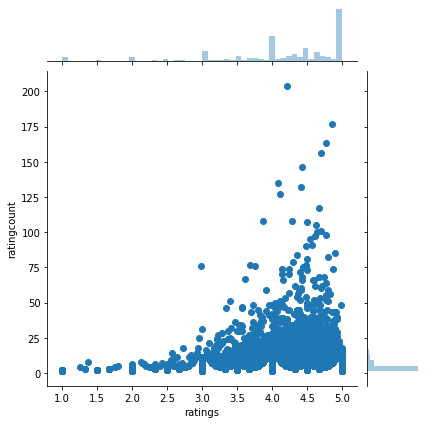

In [33]:
#Create a joint plot
sns.jointplot(x='ratings', y='ratingcount', data=product_rating_df)
# Top most rating show highest rating counts indicating that many people have rated few products highly 

In [37]:
#Popularity based recommendations (Rating > equalto 4 and rating is highest in the group to ensure that
#rating value is not due to only one person buying and giving it high rating)
product_rating_df = product_rating_df[product_rating_df.ratings >= 4]
product_rating_df.sort_values('ratingcount', ascending=False).head(10)


#The following products can be recommended as popular items to all the users.
#All these items have ratings above 4 and rating counts is in hundreds 

,ratings,ratingcount
productid,,
B0088CJT4U,4.215686,204
B003ES5ZUU,4.858757,177
B000N99BBC,4.773006,163
B007WTAJTO,4.692308,156
B00829TIEK,4.431507,146
B008DWCRQW,4.088889,135
B00829THK0,4.409091,132
B002R5AM7C,4.118110,127
B004CLYEDC,4.666667,117


**Load Dataset in surprise**

In [0]:
!pip install -q surprise

In [0]:
from surprise.model_selection import cross_validate, train_test_split
from surprise import Dataset
from surprise.reader import Reader

#Reader class is used to parse a file containing ratings.Such a file is assumed to specify only one rating per line, 
#and each line needs to respect the following structure: user ; item ; rating ; [timestamp]. We have already removed optional
# timestamp column Default rating scale of
# 1to 5 is applicable
reader = Reader()
data = Dataset.load_from_df(elect_dense_df[['userid', 'productid', 'ratings']], reader)

**4. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio).**




In [40]:
# sample random trainset and testset
# Split it in 70/30 ratio
trainset, testset = train_test_split(data, test_size=.30)
print(type(trainset))


<class 'surprise.trainset.Trainset'>


 **5. Build Collaborative Filtering model.**

**COLLABORATIVE FILTERING**
We intend to  build a system that can automatically recommend products to users based on the preferences of other users, the first step is to find similar users or products. Next step is to predict the ratings of the items that are not yet rated by a user.
The Steps we have adopted are:
1. Basic KNNWithMeans with user-user similarity and other default values is evaluated
2. Next we use combination of Hyperparameters and also try user-based and item-based options in GridSearchCV and find best parameter combination and accuracy
3. Try SVD based collaborative filtering and tune hyperparameters using
GridSearchCV
4. Find the best model and corresponding Hyperparameters
5. Run the best model and calculate performance metrics 

***User User and Item-Item Collaborative filtering-Build and Evaluate***

In [0]:
#For returning top n recommendations we use defaultdict
from collections import defaultdict
from surprise.model_selection import GridSearchCV

***KNNWithMeans Default-For Baselining***

In [42]:
# Two users can be considered similar if they give similar ratings to ten products despite there being huge difference in their age i.e. we dont need information on 
# donot need user's age , gender etc for collaborative filtering
# We identify users similar to a specific user by comparing the ratings they have given to the products. Using these ratings we will be 
# able to identify users having similar liking. So based on products liked by similar users, the product purchased by one user can be recommened
# to other user

from surprise import KNNWithMeans, accuracy

# STEP 1 - DEFAULT MODEL
#Default KNNMeans Model 
# Default max neighbours are 40 and min are 1
# Default similarity measure is MSD and user based
algo = KNNWithMeans()
algo.fit(trainset)
predictions = algo.test(testset)

print("User-based KNNWithMeans Default Model : Test accuracy")
accuracy.rmse(predictions, verbose=True)
accuracy.mae(predictions, verbose=True)

# OBSERVATION : Default KNNWith Means Test performance is RMSE: 1.0462, MAE: 0.7371
# with default max neighbour count of 40, similarity measure of MSD and user-user collaboration

Computing the msd similarity matrix...
Done computing similarity matrix.
User-based KNNWithMeans Default Model : Test accuracy
RMSE: 1.0435
MAE:  0.7363


0.7362729286945126

***KNNMeans Hyperparameter Tuning- GridSearch [Compares user-user and item-item collaborative filtering as well]***

In [0]:
# Parameters to be tuned are
#k (int) – Maximum number of neighbors for aggregation (Default is 40)
#sim_options (dict) – A dictionary of options for the similarity measure. 
#Trying user-user and item-item similarity options and choosing the best

In [79]:
param_grid = {'k': [10, 35, 40, 45],
              'sim_options': {'name': ['pearson_baseline', 'cosine', 'msd'],
                              'user_based': [True, False]}
              }

gs = GridSearchCV(KNNWithMeans, param_grid, measures=['rmse', 'mae'], cv=3)
#GridSearch doesnot work with splitted train and test
gs.fit(data)

# We can now use the algorithm that yields the best rmse:
algo = gs.best_estimator['rmse']  # pass the best model to algo
print("\n\nBest RMSE Estimator is  ",gs.best_estimator['rmse'])
print("Best RMSE Score is  ",gs.best_score['rmse'])
print("Best parameters are  ",gs.best_params['rmse'])

# Do cross validation on best parameters
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

# OBSERVATION:
#Best RMSE Score is   1.0303044334260945
#Best parameters are    {'k': 40, 'sim_options': {'name': 'pearson_baseline', 'user_based': True}}
# CROSS VALIDATION SCORE
#                   Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
# RMSE (testset)    1.0337  1.0225  1.0412  1.0374  1.0367   1.0343 0.0064  
# MAE (testset)     0.7372  0.7335  0.7448  0.7407  0.7392  0.7391  0.0038  
# Fit time          0.51    0.58    0.54    0.51    0.55    0.54    0.03    
# Test time         0.43    0.43    0.41    0.54    0.42    0.45    0.05        

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity ma

{'fit_time': (0.5357844829559326,
  0.5504529476165771,
  0.5469298362731934,
  0.5174248218536377,
  0.4889671802520752),
 'test_mae': array([0.74223354, 0.73830311, 0.74395609, 0.73921391, 0.73371678]),
 'test_rmse': array([1.03807448, 1.03442449, 1.03745506, 1.03808656, 1.02367614]),
 'test_time': (0.4280202388763428,
  0.41660499572753906,
  0.41516876220703125,
  0.3949406147003174,
  0.4075205326080322)}

**Final Model Building, Performance and Predictions**

***Final Model***

In [76]:
# Best performance was with following parameters
#Best parameters are   {'k': 40, 'sim_options': {'name': 'pearson_baseline', 
#'user_based': True}}

similarity_options = {'name': 'pearson_baseline', 'user_based': True}

finalModel = KNNWithMeans(k=40, sim_options=similarity_options )
finalModel.fit(trainset)
predictions = finalModel.test(testset)

print("User-based KNNWithMeans with K=40 , Similarity Measure Pearson Baseline Final Model : Test accuracy")
accuracy.rmse(predictions, verbose=True)
accuracy.mae(predictions, verbose=True)

#OBSERVATION:
# RMSE : 1.0292 MAE:0.7413

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
User-based KNNWithMeans with K=40 , Similarity Measure Pearson Baseline Final Model : Test accuracy
RMSE: 1.0292
MAE:  0.7413


0.741333993973445

***Final Model - Predictions***

In [83]:
#predictions contains following information:
#uid — the user ID, for whom we carry out predictions
#iid — item ID (here we treat electronic product as items)
#rui --actual rating
#est — estimated rating for an item, as we expect the user to give
#details
knn_prediction_df = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])
print("Shape of predictions are ",knn_prediction_df.shape)

#Adding an error column as well to calculate difference between actual and predicted ratings
knn_prediction_df['err'] = abs(knn_prediction_df.est - knn_prediction_df.rui)

#5 predictions(NOT RECOMMENDATIONS) (not sorted)
knn_prediction_df.head()

Shape of predictions are  (22908, 5)


,uid,iid,rui,est,details,err
0,A3RGJ1FXOB1ZLL,B000MECAPW,5.0,4.298891,"{'was_impossible': True, 'reason': 'User and/o...",0.701109
1,A17HMM1M7T9PJ1,B009Y68QIY,4.0,4.242424,"{'actual_k': 0, 'was_impossible': False}",0.242424
2,A3JLOIXFM75QNV,B005DOUJL8,5.0,4.750464,"{'actual_k': 3, 'was_impossible': False}",0.249536
3,A1Y051MQ2SVPFI,B003ZTVDIQ,5.0,4.298891,"{'was_impossible': True, 'reason': 'User and/o...",0.701109
4,A32AK8FOAZEPE2,B002QEBMAK,5.0,1.129497,"{'actual_k': 2, 'was_impossible': False}",3.870503


In [80]:
#print("Predictions having high error values: ")
knn_prediction_df[knn_prediction_df.err>3.5].count()

#Observation
# Total 165 big error values are found amongst 22908 predictions[0.72%]

uid        165
iid        165
rui        165
est        165
details    165
err        165
dtype: int64

In [81]:
#With actual and predicted rating matching
knn_prediction_df[knn_prediction_df.err== 0].count()

#Observation
# Total 1438 values are having 0 error (actual and predicted ratings are matching)
# amongst 22908 predictions [6.2%]

uid        1438
iid        1438
rui        1438
est        1438
details    1438
err        1438
dtype: int64

In [58]:
#Predictions with least error in ratings
knn_prediction_df.sort_values(by='err')[:5]

,uid,iid,rui,est,details,err
2577,A1X1CEGHTHMBL1,B001E1Y5O6,5.0,5.0,"{'actual_k': 3, 'was_impossible': False}",0.0
11389,A22S7D0LP8GRDH,B003M0NURK,5.0,5.0,"{'actual_k': 2, 'was_impossible': False}",0.0
15417,A4WEZJOIZIV4U,B00IRRDHUI,5.0,5.0,"{'actual_k': 2, 'was_impossible': False}",0.0
17044,A2FRKEXDXDN1KI,B00CRJWW2G,5.0,5.0,"{'actual_k': 3, 'was_impossible': False}",0.0
1485,A3RGJ1FXOB1ZLL,B001TH7GSW,5.0,5.0,"{'actual_k': 1, 'was_impossible': False}",0.0


In [59]:
#Predictions with worst error in ratings
knn_prediction_df.sort_values(by='err')[-5:]

,uid,iid,rui,est,details,err
19624,AN81JUYW2SL24,B000069K98,1.0,5.0,"{'actual_k': 1, 'was_impossible': False}",4.0
1370,A3S5WYWYKSAI9C,B003BLQHN4,5.0,1.0,"{'actual_k': 1, 'was_impossible': False}",4.0
10010,A38NELQT98S4H8,B008CS5T76,5.0,1.0,"{'actual_k': 1, 'was_impossible': False}",4.0
22238,A1H98YV5K5BUX0,B000TXZIDM,1.0,5.0,"{'actual_k': 1, 'was_impossible': False}",4.0
6951,A680RUE1FDO8B,B005LMWPYG,1.0,5.0,"{'actual_k': 1, 'was_impossible': False}",4.0


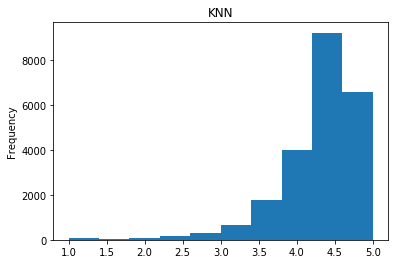

In [60]:
#Checking distribution of estimated ratings
knn_prediction_df.est.plot(kind='hist', title='KNN')
#Maximum predictions are having rating of 4.5

***Final Model-  Precision and Recall***

In [86]:
from surprise.model_selection import KFold


def precision_recall_at_k(predictions, k=10, threshold=3.5):
    '''Return precision and recall at k metrics for each user.'''

    # First map the predictions to each user.
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 1

        # Recall@K: Proportion of relevant items that are recommended
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 1

    return precisions, recalls



kf = KFold(n_splits=5)
#Take Final Model built by us
algo = finalModel

for trainset, testset in kf.split(data):
    algo.fit(trainset)
    predictions = algo.test(testset)
    precisions, recalls = precision_recall_at_k(predictions, k=5, threshold=4)

# Precision and recall can then be averaged over all users
print("\n\n")
print("Average precision for all users is = ",sum(prec for prec in precisions.values()) / len(precisions))
print("Average recall for all users is = ",sum(rec for rec in recalls.values()) / len(recalls))

#Observation:
#Average precision for all users is =  0.8599385245901585
#Average recall for all users is =  0.5207068079568247

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.



Average precision for all users is =  0.8599385245901585
Average recall for all users is =  0.5207068079568247


***Final Model - Top 5 Recommendations***

In [0]:
# Function to Return the top-N recommendation for each user from a set of predictions.
#
# Args:
# predictions(list of Prediction objects): The list of predictions, as
# returned by the test method of an algorithm.
# n(int): The number of recommendation to output for each user. Default
# is 10.
#
# Returns:
# A dict where keys are user (raw) ids and values are lists of tuples:
#        [(raw item id, rating estimation), ...] of size n.
def get_top_n(predictions, n=10):
    # First map the predictions to each user.
    top_n = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))#For each userid store product id and rating estimate

    # Then sort the predictions for each user and retrieve the n highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)#sort ratings for each productid
        top_n[uid] = user_ratings[:n]#assign sorted tuples of ratings along with product

    return top_n

In [62]:
#Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to
#each user based on his/her habits, we will recommend 5 new products.
top5 = get_top_n(predictions, 5)

# Print the recommended items for all the users - UNCOMMENT FOLLOWING
#print("USER ID  [TOP 5 RECOMMENDED PRODUCTS]")
#for uid, user_ratings in top5.items():
#    print(uid, [iid for (iid, _) in user_ratings])

print("TOP 5 RECOMMENDED PRODUCTS FOR 10 USERS")

# Get first 10 users from dictionary 
out_dict = dict(list(top5.items())[0: 10]) 

for uid, user_ratings in out_dict.items():
    print("For user ",uid, ": top 5 product recommendation :",[iid for (iid, _) in user_ratings])


TOP 5 RECOMMENDED PRODUCTS FOR 10 USERS
For user  A3RGJ1FXOB1ZLL : top 5 product recommendation : ['B002W4M0DW', 'B001TH7GSW', 'B00ALK3HF4', 'B003FWHTTA', 'B000BUDHOA']
For user  A17HMM1M7T9PJ1 : top 5 product recommendation : ['B002J9HBSE', 'B004M8ST5Y', 'B00DR6DQZA', 'B00G4UQ6U8', 'B001D9IWIY']
For user  A3JLOIXFM75QNV : top 5 product recommendation : ['B001AGM2VI', 'B0090IA4FO', 'B003FST9EC', 'B002FB684E', 'B005DOUJL8']
For user  A1Y051MQ2SVPFI : top 5 product recommendation : ['B007I5JT4S', 'B003ZTVDIQ', 'B00BC4SL18', 'B008FQMUL8', 'B001ELJ9QK']
For user  A32AK8FOAZEPE2 : top 5 product recommendation : ['B005BNWKD6', 'B007P8I3K4', 'B001FFU1GC', 'B0045Y1IMQ', 'B005E7TE9W']
For user  A3UKWQS8SRW6IO : top 5 product recommendation : ['B0040702HA', 'B00HFRWWAM', 'B00829THVO', 'B00AYB3OMG', 'B005KOZNBW']
For user  A11I1I9QLMAM1A : top 5 product recommendation : ['B001DJ9GOS', 'B00C28L138', 'B009PK9S90', 'B00DQZPCTA', 'B002TLTE6Y']
For user  A28UMA3GW9L124 : top 5 product recommendation :

**Conclusions/Insights**

In [0]:
#1. Users count is 10 times the products
#2. Maximum rating count is for rating of 5
#3. For complete dataset:
#   Total Users 7824481 
#   Most active user is A5JLAU2ARJ0BO,Most in demand product is B0074BW614, Total Unique users:	4201696,Total Unique products:476001
#4. For subset dataset:
#   Total Users 76359
#   Most active user is ADLVFFE4VBT8,Most in demand product is B0088CJT4U,Total Unique Users :1466, Total Unique Products:16555
#
# 5 Popularity BAsed Filtering [Mean rating above 4 and highest rating counts were considered]. We concluded
# highest mean rating could be due to very few users rating the product very high so we considered mean rating above 4
# and top 5 rating count amongst highly rated products
# Top 5 Popular items are :
# Product     MeanRate  RateCount
# B0088CJT4U	4.215686	204
# B003ES5ZUU	4.858757	177
# B000N99BBC	4.773006	163
# B007WTAJTO	4.692308	156
# B00829TIEK	4.431507	146
#
#5 OBSERVATION : BASELINE MODEL - Default KNNWith Means Test performance is RMSE: 1.0462, MAE: 0.7371
# with default max neighbour count of 40, similarity measure of MSD and user-user collaboration
#
#6 OBSERVATION : OPTIMAL MODEL - Grid search showed optimal performance vis a vis RMSE  with user-user collaboration [Not with item item]
# Best similarity measure was Pearson_Baseline
# RMSE : 1.0343 MAE:0.7393 
# Tried different max neighbour size from 5 to 60 and the performance did not degrade till 40 so max 40 users were taken as neighbours
# However, inspite of considering 40 (maximum amoungst optimal) neighbours, the count of error values (whose actual and predicted
# rating was different) was not reduced(below 165).
# 
# a. THis indicates there are not many similar matching neighbours in the dataset so user user collaboration is not affected
# much by changing nearest neighbours
# 
# b. Since in original dataset users are almost 10 times items so user-user similarity vis a vis product buying pattern
# chances are more than item item similarity [Two users can rate similar items but two items cannot be rated by similar
# users]
# 
#
# 7 OBSERVATION: FINAL MODEL Took optimal parameters of max 40 users, pearson_baseline similarity measure and user-user
# collaborative filtering
# RMSE : 1.0292 MAE:0.7413 [Marginal improvement from Baseline model]
#
# Prediction Error > 3.5 was around 0.7%
# Actual and predicted rating were exactly matching in 6.2% cases
# Marginal error was for 93% cases i.e. difference between actual and predicted rating was less than 3.5
#
# Average precision for all users is =  0.8599385245901585
# Average recall for all users is =  0.5207068079568247